In [90]:
# import libraries for sentiment analysis
import os
from newsapi import NewsApiClient
import pandas as pd
from dotenv import load_dotenv, find_dotenv
import datetime
from pathlib import Path
import string
from collections import Counter
import matplotlib.pyplot as plt
# https://www.youtube.com/watch?v=lcgqP8g6i84&list=PLhTjy8cBISEoOtB5_nwykvB9wfEDscuEo&index=3

In [ ]:
# # get API key from env
# env_path = find_dotenv()    # returns path string or "" if none found

# # load the key from the .env fiole 
# api_key = os.environ.get("NEWS_API_KEY")  
# newsapi = NewsApiClient(api_key=api_key)
# # print(api_key)

In [ ]:
# def get_news(query):
#     api_key = os.environ.get("NEWS_API_KEY")
#     newsapi = NewsApiClient(api_key=api_key)

#     to_date = datetime.date.today()
#     from_date = to_date - datetime.timedelta(days=7)
#     from_str = from_date.isoformat()
#     to_str = to_date.isoformat()

#     PAGE_SIZE = 100
#     MAX_ARTICLES = 10

#     articles = []
#     page = 1
#     while len(articles) < MAX_ARTICLES:
#         resp = newsapi.get_everything(
#             q=query,
#             from_param=from_str,
#             to=to_str,
#             language="en",
#             page=page,
#             page_size=PAGE_SIZE,
#             sort_by="publishedAt"
#         )
#         hits = resp.get("articles", []) or []
#         if not hits:
#             break

#         for a in hits:
#             articles.append({
#                 "source": (a.get("source") or {}).get("name"),
#                 "author": a.get("author"),
#                 "title": a.get("title"),
#                 "description": a.get("description"),
#                 "url": a.get("url"),
#                 "publishedAt": a.get("publishedAt"),
#                 "content": a.get("content")
#             })
#             if len(articles) >= MAX_ARTICLES:
#                 break

#         page += 1
#         total_results = resp.get("totalResults") or 0
#         if page > (total_results // PAGE_SIZE) + 1:
#             break

#     return pd.DataFrame(articles)

# df_news = get_news("Stock Market")
# # print(df_news.head())

In [ ]:
# text = ""
# text_articles = get_news("Stock Market")
# length = text_articles.shape[0]
# # print(f"Number of articles fetched: {length}")

# for i in range(0, length):
#     text = text_articles['title'][i] + " " + text

# # print(text)
# # titles = df_news['title'].dropna().tolist()
# # titles

# titles_big_list = [[t.strip()] for t in df_news['title'].dropna() if t.strip()]
# print(titles_big_list)

In [ ]:
text_path = Path("training_data/text_data.csv")
df = pd.read_csv(text_path, encoding="cp1252", low_memory=False,) 

# print(df.head())

# convert text to lower case 
lower_case_text = df['Text'].str.lower()
# print(lower_case_text.head())

# remove punctuation - converting string to string without prunctuations
cleaned_text = lower_case_text.str.translate(str.maketrans('', '', string.punctuation))
# print(cleaned_text.head())

### Tokenisation

In [97]:
tokenise_words = cleaned_text.str.split() # get words sperated by space and store in a list
print(tokenise_words.head())

0    [budget, to, set, scene, for, election, gordon...
1    [army, chiefs, in, regiments, decision, milita...
2    [howard, denies, split, over, id, cards, micha...
3    [observers, to, monitor, uk, election, ministe...
4    [kilroy, names, election, seat, target, exchat...
Name: Text, dtype: object


In [98]:
# stop words - remove any words that dont add any value to the sentence - like : is, am, the , a , an , in , on , at , for.
stop_words = ["i","me","my","myself","we","our","ours","ourselves","you","your","yours","yourself","yourselves","he","him","his","himself","she","her",
              "hers","herself","it","its","itself","they","them","their","theirs","themselves","what","which","who","whom","this","that","these","those",
              "am","is","are","was","were","be","been","being","have","has","had","having","do","does","did","doing","a","an","the","and","but","if","or",
              "because","as","until","while","of","at","by","for","with","about","against","between","into","through","during","before","after","above",
              "below","to","from","up","down","in","out","on","off","over","under","again","further","then","once","here","there","when","where","why",
              "how","all","any","both","each","few","more","most","other","some","such","no","nor","not","only","own","same","so","than","too","very",
              "s","t","can","will","just","don","should","now"]

In [99]:
# final_words = []
# for word in tokenise_words:
#     # add words not in stop words to the list 
#     if word not in stop_words:
#         final_words.append(word) 

# print(final_words[:5])

stop_words_set = set(stop_words)
final_words = []
for token_list in tokenise_words:
    for w in token_list:
        w = w.strip()
        if w and w not in stop_words_set:
            final_words.append(w)

print(final_words[:50])

['budget', 'set', 'scene', 'election', 'gordon', 'brown', 'seek', 'put', 'economy', 'centre', 'labours', 'bid', 'third', 'term', 'power', 'delivers', 'ninth', 'budget', '1230', 'gmt', 'expected', 'stress', 'importance', 'continued', 'economic', 'stability', 'low', 'unemployment', 'interest', 'rates', 'chancellor', 'expected', 'freeze', 'petrol', 'duty', 'raise', 'stamp', 'duty', 'threshold', 'ã‚â£60000', 'conservatives', 'lib', 'dems', 'insist', 'voters', 'face', 'higher', 'taxes', 'meanstesting', 'labour']


In [100]:
# check if the word in the final wordes list is in the emotions list 

emotions_list = []
emotions_file = Path("training_data/emotions.txt")
with open(emotions_file,'r') as file:
    for line in file:
        clear_line = line.replace("\n",'').replace(",",'').replace("'",'').strip()
        word, emotion = clear_line.split(':')
        # print("Word:", word, "Emotion:", emotion)

        if word in final_words:
            emotions_list.append(emotion)

print("Emotions detected:", emotions_list)
w = Counter(emotions_list)
print(w)

Emotions detected: [' cheated', ' singled out', ' loved', ' attracted', ' sad', ' fearful', ' angry', ' happy', ' angry', ' attracted', ' bored', ' angry', ' esteemed', ' lustful', ' lustful', ' attached', ' attracted', ' embarrassed', ' attached', ' cheated', ' surprise', ' angry', ' powerless', ' sad', ' fearless', ' bored', ' fearless', ' happy', ' happy', ' safe', ' adequate', ' attached', ' powerless', ' fearful', ' fearless', ' attracted', ' cheated', ' happy', ' attached', ' fearful', ' happy', ' average', ' adequate', ' apathetic', ' adequate', ' attracted', ' adequate', ' surprise', ' attached', ' obsessed', ' happy', ' powerless', ' fearless', ' fearful', ' sad', ' angry', ' sad', ' attracted', ' fearless', ' sad', ' attracted', ' powerless', ' belittled', ' sad', ' sad', ' hated', ' sad', ' alone', ' focused', ' belittled', ' demoralized', ' hated', ' belittled', ' powerless', ' belittled', ' angry', ' demoralized', ' demoralized', ' derailed', ' sad', ' fearful', ' sad', ' 

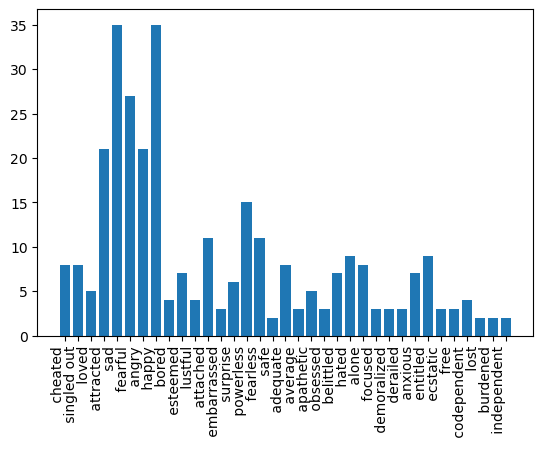

In [101]:
fig, axl = plt.subplots()
axl.bar(w.keys(), w.values())
fig.autofmt_xdate() # automatically update the axis to format all values 
plt.savefig('emotion_analysis.png')
plt.xticks(rotation=90)
plt.show()


Emotions detected: [' average']
Counter({' average': 1})


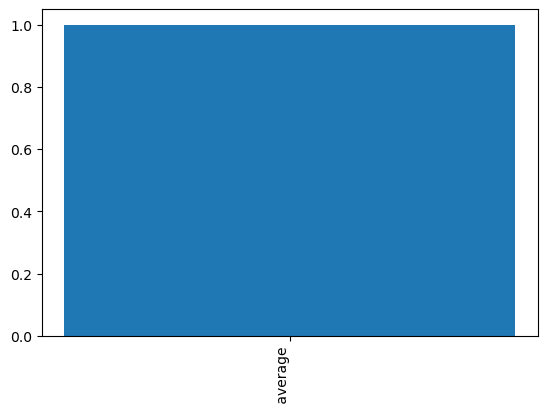

In [102]:
from pathlib import Path
import string
from collections import Counter
import matplotlib.pyplot as plt

# Fetch recent news (only argument is the query)
df_news = get_news("Stock Market")

# Prepare titles: lowercase, remove punctuation, split into tokens
titles = df_news['title'].dropna().astype(str).tolist()
lower_titles = [t.lower() for t in titles]
cleaned_titles = [t.translate(str.maketrans('', '', string.punctuation)) for t in lower_titles]
tokenise_titles = [t.split() for t in cleaned_titles]

# Remove stop words (uses stop_words list already in your notebook)
stop_words_set = set(stop_words)
final_words = [w for token_list in tokenise_titles for w in token_list if w and w not in stop_words_set]

# Map words -> emotions using training_data/emotions.txt (format: word:emotion per line)
emotions_list = []
emotions_file = Path("training_data/emotions.txt")
with open(emotions_file, 'r') as file:
    for line in file:
        clear_line = line.replace("\n", "").replace(",", "").replace("'", "").strip()
        word, emotion = clear_line.split(':')
        if word in final_words:
            emotions_list.append(emotion)

print("Emotions detected:", emotions_list)
w = Counter(emotions_list)
print(w)

# Optional: simple bar plot like you had before
fig, ax = plt.subplots()
ax.bar(w.keys(), w.values())
fig.autofmt_xdate()
plt.xticks(rotation=90)
plt.show()